In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import epiweeks as ew


In [32]:
#read in table
df = pd.read_csv('../data/importations/sarscov2_clusters_2024_11_12_filtered.tsv.gz', sep='\t')
df.head()
#region unique value counts
df['region'].value_counts()

region
California       33881
Washington       15450
Virginia         15163
Massachusetts    13698
Minnesota        12970
Georgia          12731
Name: count, dtype: int64

In [7]:
df.head()

,cluster_id,sample_count,earliest_date,latest_date,growth_score,span,intro_confidence,parent_confidence,origin_gap,region,...,annotation_1,annotation_2,mutation_path,samples,annotation_3,week,year,week_year,genbank_seed,strain_seed
0,Washington_node_1685550,2,NaT,no-valid-date,1.41421,0,1.0,0.000000,3,Washington,...,20C,B.1.369,"T21580C<G19872T<G806A,C4582T,C24937T,T28879C<C...","USA/WA-EPICC_Sieve_122/2021|OR611276.1|2021,US...",NaN,NaN,NaN,NaN,OR611276.1,USA/WA-EPICC_Sieve_122/2021
1,Washington_node_1677062,1,NaT,no-valid-date,1.00000,3,1.0,0.000000,1,Washington,...,21C (Epsilon),B.1.429,"C2706T<G28191T<G28975T<C8947T,C12100T<A12878G<...",USA/WA-EPICC_Sieve_084/2020|OR611239.1|2020,NaN,NaN,NaN,NaN,OR611239.1,USA/WA-EPICC_Sieve_084/2020
2,Washington_node_61895,1,NaT,no-valid-date,1.00000,1,1.0,0.050000,1,Washington,...,20G,B.1.2,"C13426T<C7869T,G23873T<G2585T<G4288T<G28361C<T...",USA/WA-EPICC_Sieve_010/2020|OR611165.1|2020,NaN,NaN,NaN,NaN,OR611165.1,USA/WA-EPICC_Sieve_010/2020
3,Washington_node_40915,1,NaT,no-valid-date,1.00000,0,1.0,0.181818,1,Washington,...,20A,B.1.596,"C16323T,G24751A,C24865T<A9750G,C20016T,A29005T...",USA/WA-EPICC_Sieve_121/2021|OR611275.1|2021,NaN,NaN,NaN,NaN,OR611275.1,USA/WA-EPICC_Sieve_121/2021
4,Washington_node_51347,1,NaT,no-valid-date,1.00000,2,1.0,0.038462,1,Washington,...,20G,B.1.2,C19328T<C19269T<G29402T<G8083A<C14805T<C21304T<,USA/WA-EPICC_Sieve_120/2021|OR611274.1|2021,NaN,NaN,NaN,NaN,OR611274.1,USA/WA-EPICC_Sieve_120/2021


In [8]:
#for annotation_3 == B.1.617.2, and region == 'Virginia' count the total number of comma separated values in samples column
df.loc[(df['annotation_3'] == 'B.1.617.2') & (df['region'] == 'Virginia'), 'samples'].str.split(',').apply(len).sum()

np.int64(18116)

In [ ]:
#how many regions are Virginia

Index(['cluster_id', 'sample_count', 'earliest_date', 'latest_date',
       'growth_score', 'span', 'intro_confidence', 'parent_confidence',
       'origin_gap', 'region', 'inferred_origin', 'inferred_origin_confidence',
       'annotation_1', 'annotation_2', 'mutation_path', 'samples',
       'annotation_3', 'week', 'year', 'week_year'],
      dtype='object')

In [3]:
#create genbank_seed column by splitting samples column based on ',' then based on '|' and taking the second element
df['genbank_seed'] = df['samples'].str.split(',').str[0].str.split('|').str[1]
#create strain_seed column by splitting samples column based on ',' then based on '|' and taking the first element
df['strain_seed'] = df['samples'].str.split(',').str[0].str.split('|').str[0]
df.head()

,cluster_id,sample_count,earliest_date,latest_date,growth_score,span,intro_confidence,parent_confidence,origin_gap,region,...,annotation_1,annotation_2,mutation_path,samples,annotation_3,week,year,week_year,genbank_seed,strain_seed
0,Washington_node_1685550,2,NaN,no-valid-date,1.41421,0,1.0,0.000000,3,Washington,...,20C,B.1.369,"T21580C<G19872T<G806A,C4582T,C24937T,T28879C<C...","USA/WA-EPICC_Sieve_122/2021|OR611276.1|2021,US...",NaN,NaN,NaN,NaN,OR611276.1,USA/WA-EPICC_Sieve_122/2021
1,Washington_node_1677062,1,NaN,no-valid-date,1.00000,3,1.0,0.000000,1,Washington,...,21C (Epsilon),B.1.429,"C2706T<G28191T<G28975T<C8947T,C12100T<A12878G<...",USA/WA-EPICC_Sieve_084/2020|OR611239.1|2020,NaN,NaN,NaN,NaN,OR611239.1,USA/WA-EPICC_Sieve_084/2020
2,Washington_node_61895,1,NaN,no-valid-date,1.00000,1,1.0,0.050000,1,Washington,...,20G,B.1.2,"C13426T<C7869T,G23873T<G2585T<G4288T<G28361C<T...",USA/WA-EPICC_Sieve_010/2020|OR611165.1|2020,NaN,NaN,NaN,NaN,OR611165.1,USA/WA-EPICC_Sieve_010/2020
3,Washington_node_40915,1,NaN,no-valid-date,1.00000,0,1.0,0.181818,1,Washington,...,20A,B.1.596,"C16323T,G24751A,C24865T<A9750G,C20016T,A29005T...",USA/WA-EPICC_Sieve_121/2021|OR611275.1|2021,NaN,NaN,NaN,NaN,OR611275.1,USA/WA-EPICC_Sieve_121/2021
4,Washington_node_51347,1,NaN,no-valid-date,1.00000,2,1.0,0.038462,1,Washington,...,20G,B.1.2,C19328T<C19269T<G29402T<G8083A<C14805T<C21304T<,USA/WA-EPICC_Sieve_120/2021|OR611274.1|2021,NaN,NaN,NaN,NaN,OR611274.1,USA/WA-EPICC_Sieve_120/2021


In [33]:
from pango_aliasor.aliasor import Aliasor
from typing import List, Dict
#of the variants in base_variants make a dictionary of all the subvariants that point to them
#the recombinant option is based on a request and likely not to work well.
def make_variant_base_map(base_variants: List[str], recombinant=False) -> Dict[str, str]:
    namer = Aliasor()
    namer.enable_expansion()
    all_rules = namer.partition_focus(base_variants, recombinant=recombinant)
    lineage_base_map = {k: v for v, ks in all_rules.items() for k in ks}
    
    for b in base_variants:
        if b not in lineage_base_map:
            lineage_base_map[b] = b
            
    return lineage_base_map

In [34]:
#regularize the variant names
#target_list=['B.1.617.2','B.1.1.7']
target_list = ['B.1.1.7', 'B.1.617.2', 'BA.1', 'BA.2', 'BA.4', 'BA.5', 'XBB', 'XBB.1.5', 'XBB.1.16', 'XBB.1.9', 'BA.2.86', 'KP.3', 'LP.8', 'XEC']
replace_map = make_variant_base_map(target_list)
df['annotation_3']=df['annotation_2'].map(replace_map)

#make a week year column
df['earliest_date'] = pd.to_datetime(df['earliest_date'], errors='coerce')
df['week'] = df['earliest_date'].dt.strftime('%U')
df['year'] = df['earliest_date'].dt.strftime('%Y')
df['week_year'] = df['year'] + '-' + df['week']
df['week_year'] = pd.to_datetime(df['week_year'] + '-0', format='%Y-%U-%w').dt.strftime('%Y-%U')


In [6]:
#how many are B.1.617.2 and Virginia
df[df['annotation_3'] == 'B.1.617.2'].groupby('region')['annotation_3'].count().reset_index(name='count')

,region,count
0,California,9297
1,Georgia,3780
2,Massachusetts,4977
3,Minnesota,4473
4,Virginia,3570
5,Washington,3739


/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000], labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000+'])
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_df = region_df.groupby(['bin_size','annotation_3'], as_index=False)['sample_count'].sum()


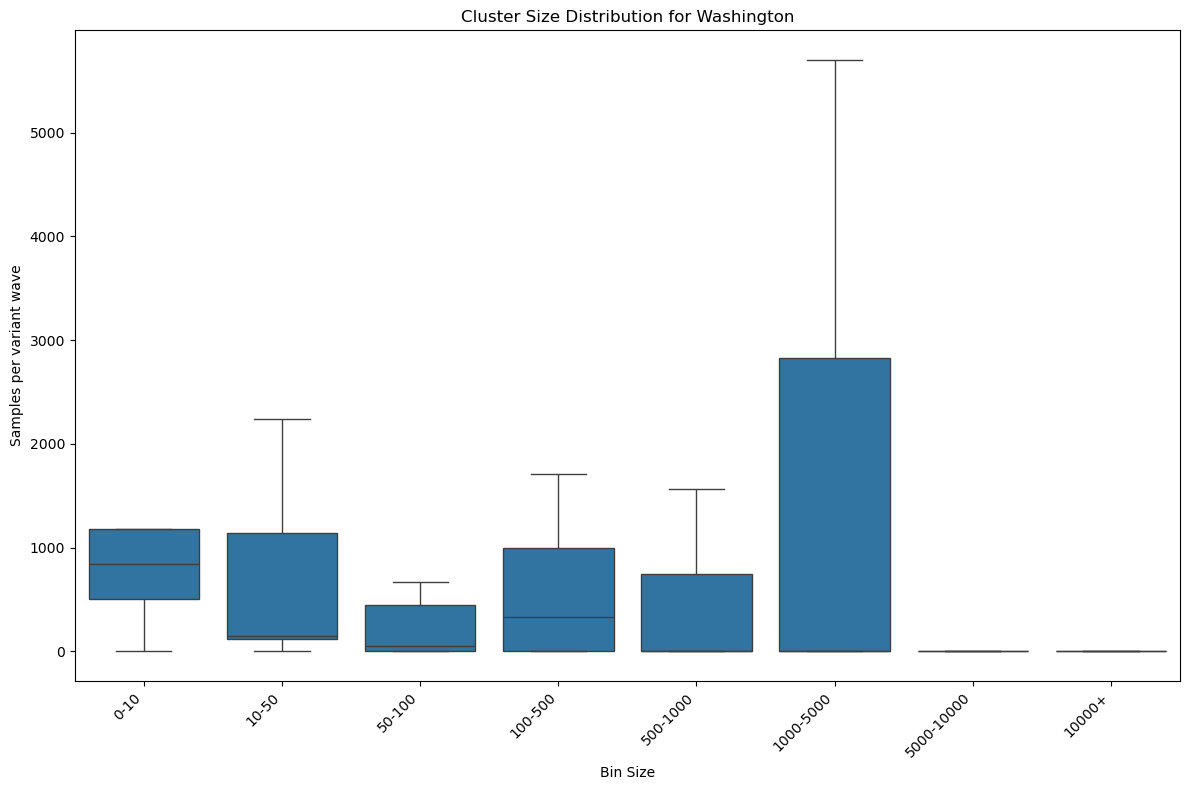

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000], labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000+'])
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_df = region_df.groupby(['bin_size','annotation_3'], as_index=False)['sample_count'].sum()


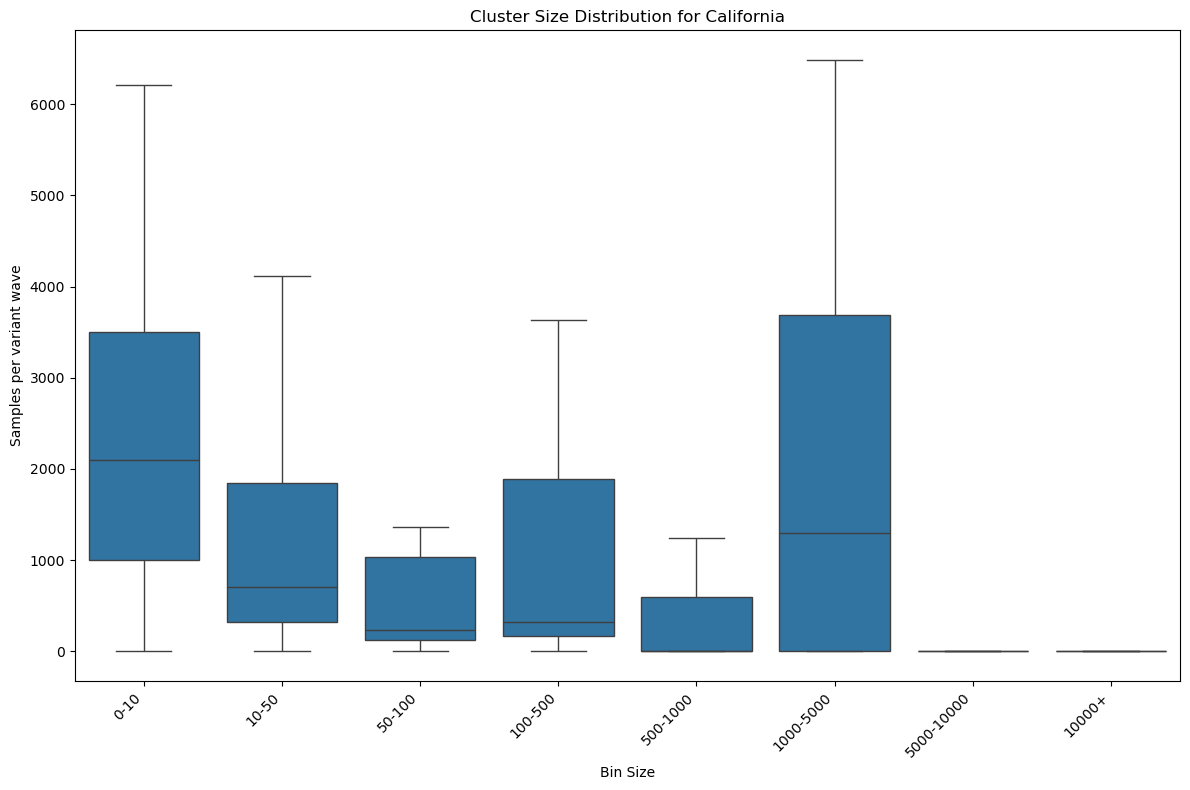

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000], labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000+'])
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_df = region_df.groupby(['bin_size','annotation_3'], as_index=False)['sample_count'].sum()


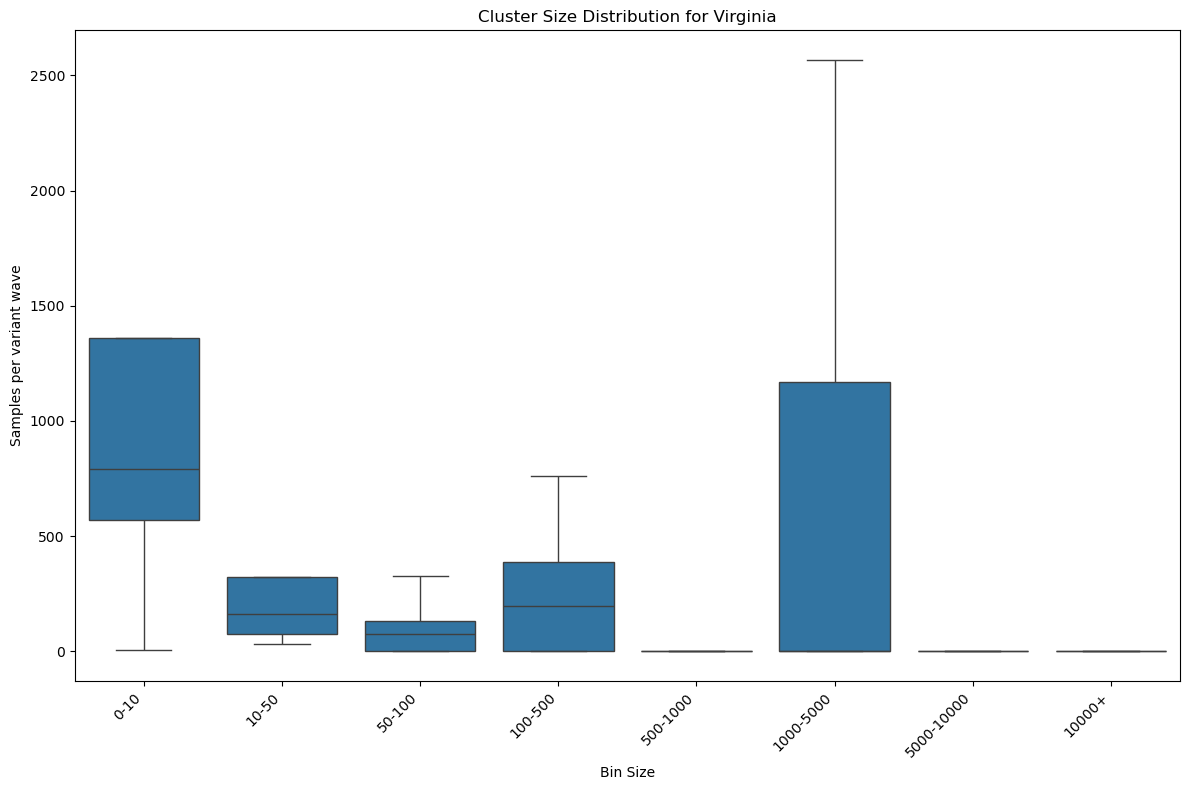

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000], labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000+'])
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_df = region_df.groupby(['bin_size','annotation_3'], as_index=False)['sample_count'].sum()


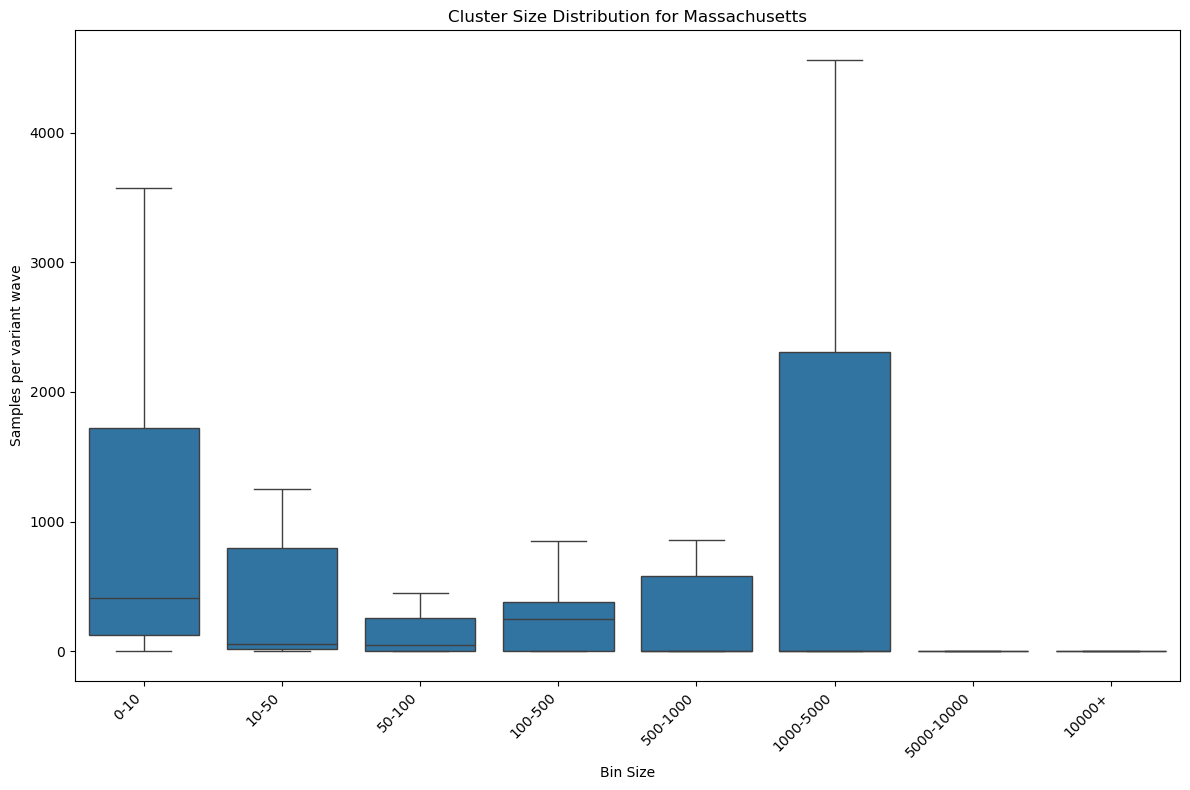

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000], labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000+'])
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_df = region_df.groupby(['bin_size','annotation_3'], as_index=False)['sample_count'].sum()


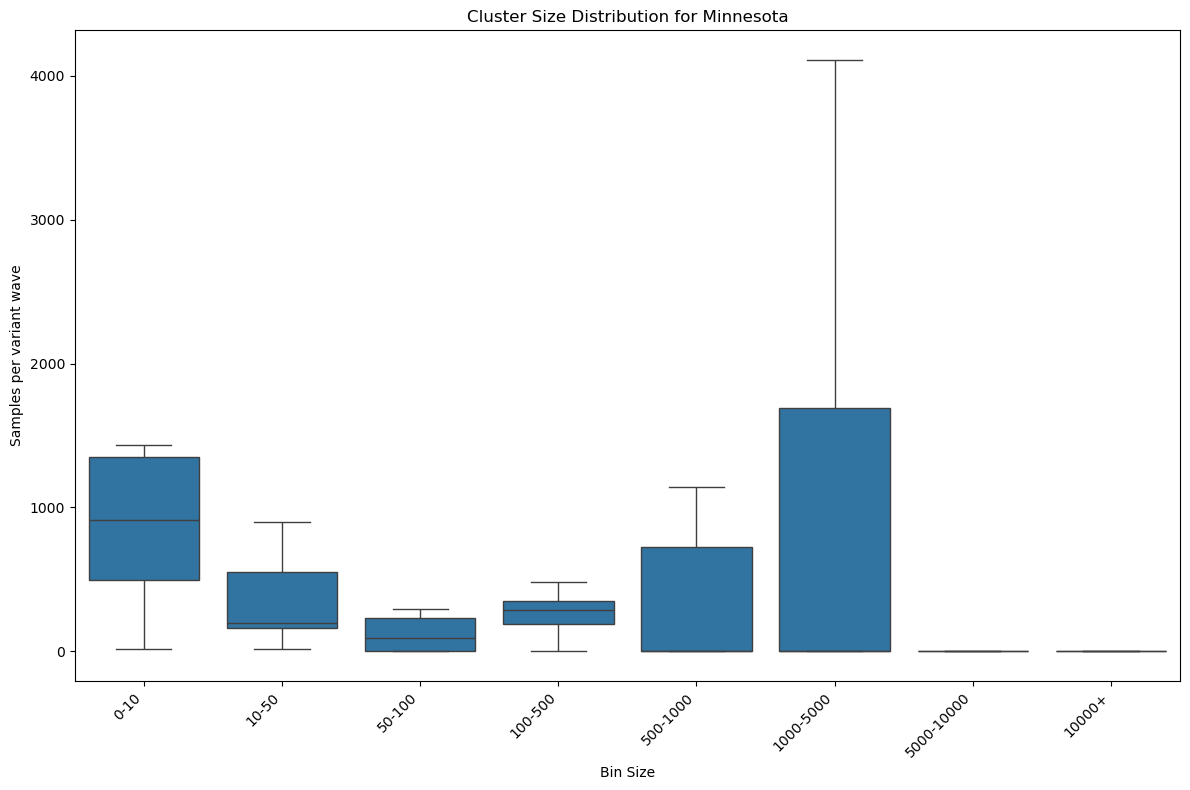

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000], labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000+'])
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3997/2348522241.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_df = region_df.groupby(['bin_size','annotation_3'], as_index=False)['sample_count'].sum()


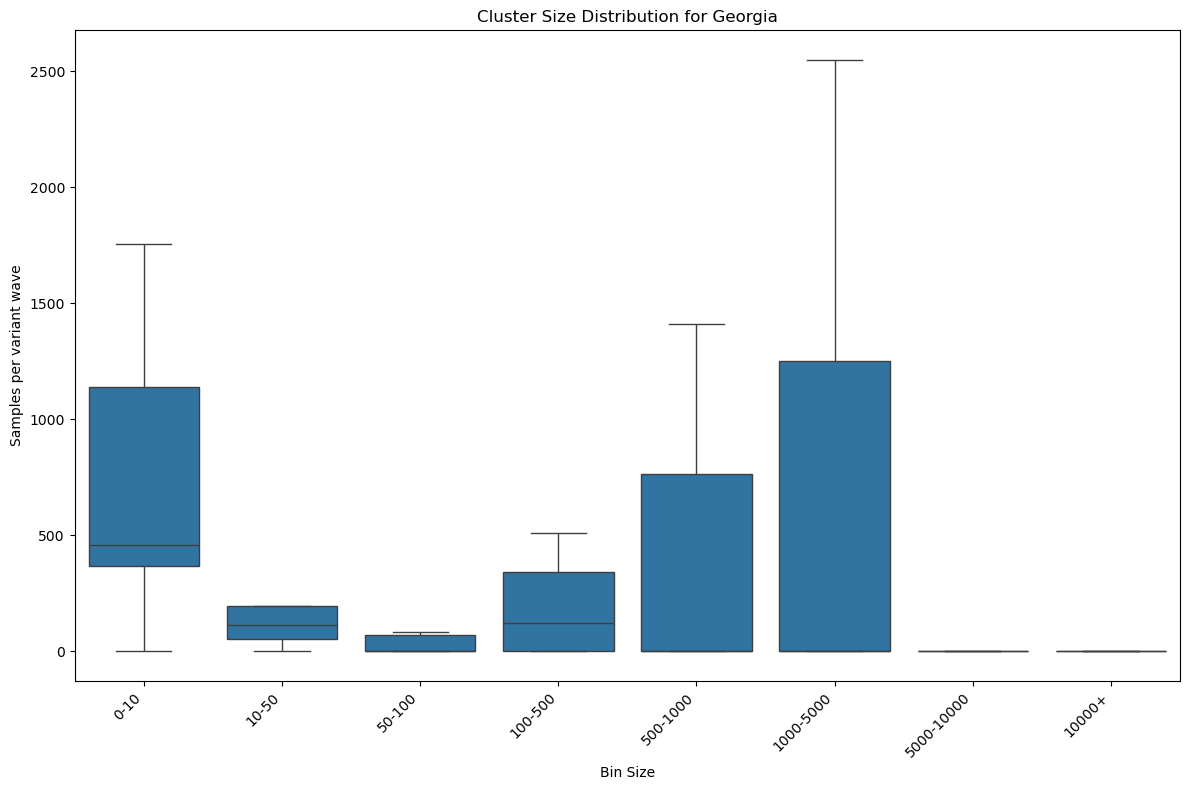

In [18]:
# Group by annotation_3 and create a boxplot for each group per region
for region in df['region'].unique():
    # Filter df for the region
    region_df = df[df['region'] == region]
    #create a bin size category based on sample_count
    region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000], labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000+'])
    #group by bin size and count the sum of sample_count per bin size.
    group_by_df = region_df.groupby(['bin_size','annotation_3'], as_index=False)['sample_count'].sum()    
    # Plot cluster size distribution as a boxplot grouped by annotation_3
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='bin_size', y='sample_count', data=group_by_df, showfliers=False)
    plt.title(f'Cluster Size Distribution for {region}')
    plt.xlabel('Bin Size')
    plt.ylabel('Samples per variant wave')
    #plt.yscale('log')  # Log scale for better visualization
    plt.xticks(rotation=45, ha='right')
    
    # Show the plot
    plt.tight_layout()
    plt.show()


In [ ]:
#sort by sample_count
df.sort_values('sample_count', ascending=False).head()
target_lineage="B.1.617.2"
#target_list = ['B.1.1.7', 'B.1.617.2', 'BA.1', 'BA.2', 'BA.4', 'BA.5', 'XBB', 'XBB.1.5', 'XBB.1.16', 'XBB.1.9', 'BA.2.86', 'KP.3', 'LP.8', 'XEC']
target_list = ['B.1.1.7', 'B.1.617.2', 'BA.1', 'BA.2', 'BA.4']
#for each region plot the cluster size distribution
for region in df['region'].unique():
    for target_lineage in target_list:
        #filter df for region
        region_df = df[(df['region'] == region) & (df['annotation_3'] == target_lineage)]
        #sort by sample_count
        region_df = region_df.sort_values('sample_count', ascending=False)
        #plot cluster size distribution
        plt.figure(figsize=(10, 6))
        sns.histplot(region_df['sample_count'], bins=30, kde=False, stat='count', color='blue')
        plt.title(f'Cluster Size Distribution for {region} - {target_lineage}')
        plt.xlabel('Cluster Size')
        plt.ylabel('Frequency')
        #log log scale
        plt.yscale('log')
       
        #plt.savefig(f'../figures/importations/cluster_size_distribution_{region}_{target_lineage}.png')
        #plt.close()
        plt.show()

    plt.show()

In [10]:
df.columns

Index(['cluster_id', 'sample_count', 'earliest_date', 'latest_date',
       'growth_score', 'span', 'intro_confidence', 'parent_confidence',
       'origin_gap', 'region', 'inferred_origin', 'inferred_origin_confidence',
       'annotation_1', 'annotation_2', 'mutation_path', 'samples',
       'annotation_3', 'week', 'year', 'week_year', 'genbank_seed',
       'strain_seed'],
      dtype='object')

In [20]:
va_df = df[(df['region'] == 'Virginia') & (df['annotation_3'] == target_lineage)]
va_df.shape

(3570, 22)

In [44]:
#how many cluster in other states start in Virginia, synthetic data
#read in table
full_df = pd.read_csv('../data/importations/full_hardcoded_clusters_us.circamarch2024.tsv.gz', sep='\t')
full_df['annotation_3']=full_df['annotation_2'].map(replace_map)
target_lineage="B.1.617.2"
#va_df = df[(df['region'] == 'Virginia') & (df['annotation_3'] == target_lineage)]
full_delta_df = full_df[ (full_df['annotation_3'] == target_lineage)]

#inferred_origins = full_delta_df['inferred_origin'].str.split(',').explode().value_counts().reset_index(name='count').rename(columns={'index': 'inferred_origin'})
inferred_origins = full_delta_df['region'].value_counts().reset_index(name='count').rename(columns={'index': 'region'})
#look up inferred_origins Virginia
print(inferred_origins[inferred_origins['region'] == 'West_Virginia'])
print(inferred_origins[inferred_origins['region'] == 'Virginia'])
print(inferred_origins[inferred_origins['region'] == 'California'])
print(inferred_origins[inferred_origins['region'] == 'Washington'])

           region  count
27  West_Virginia   2646
      region  count
14  Virginia   5671
       region  count
0  California  17646
        region  count
17  Washington   5210


In [45]:
#how many cluster in other states start in Virginia, synthetic data
#read in table
syn_df = pd.read_csv('../data/importations/hybrid_synthetic_clusters_delta.tsv', sep='\t')
syn_df['annotation_3']=syn_df['annotation_2'].map(replace_map)
target_lineage="B.1.617.2"
#va_df = df[(df['region'] == 'Virginia') & (df['annotation_3'] == target_lineage)]
syn_delta_df = syn_df[ (syn_df['annotation_3'] == target_lineage)]

#inferred_origins = syn_delta_df['inferred_origin'].str.split(',').explode().value_counts().reset_index(name='count').rename(columns={'index': 'inferred_origin'})
#look up inferred_origins Virginia
inferred_origins = syn_delta_df['region'].value_counts().reset_index(name='count').rename(columns={'index': 'region'})
#look up inferred_origins Virginia
print(inferred_origins[inferred_origins['region'] == 'West_Virginia'])
print(inferred_origins[inferred_origins['region'] == 'Virginia'])
print(inferred_origins[inferred_origins['region'] == 'California'])
print(inferred_origins[inferred_origins['region'] == 'Washington'])



           region  count
26  West_Virginia   2615
      region  count
51  Virginia     92
       region  count
0  California  17515
        region  count
16  Washington   5158


In [ ]:
#syn_delta_df how many region West_Virginia?
syn_delta_df[syn_delta_df['inferred_origin'].str.contains('West Virginia')].shape

,cluster_id,sample_count,earliest_date,latest_date,growth_score,span,intro_confidence,parent_confidence,origin_gap,region,inferred_origin,inferred_origin_confidence,annotation_1,annotation_2,mutation_path,samples,annotation_3
0,Washington_node_26270,3877,2021-May-30,2022-Jan-25,0.297921,3494,1.0,0.00000,1,Washington,"California,Georgia,Texas","1,1,1",21J (Delta),AY.44,T14014G<C6040T<C6402T<A11201G<,USA/WA-CDC-UW22012347878/2022|OM570693.1|2022-...,B.1.617.2
1,Washington_node_42939,1277,2021-Jun-21,2022-Jan-10,0.173472,1033,1.0,0.00000,1,Washington,"California,Florida,Nevada,New_Mexico,North_Car...","1,1,1,1,1,1,1,1",21J (Delta),AY.44,G28073T<C16726T<C7926T<A29700G<T14014G<C6040T<...,USA/WA-CDC-LC0496325/2022|OM494615.1|2022-01-1...,B.1.617.2
2,Washington_node_250016,1172,2021-May-31,2021-Dec-18,0.163801,1033,1.0,0.15846,1,Washington,"Minnesota,Massachusetts,California","0.0591775,0.0905336,0.101405",21J (Delta),AY.117,G14186T<C15810T<C28708T<C6402T<A11201G<,USA/WA-CDC-UW21121378815/2021|OM004423.1|2021-...,B.1.617.2
3,Washington_node_121580,664,2021-Jun-28,2021-Dec-24,0.125699,564,1.0,0.00000,1,Washington,"California,Colorado,Florida,Nevada,New_Jersey,...","1,1,1,1,1,1,1,1,1,1,1",21J (Delta),AY.103,T6661C<T27291C<A17236G<C24208T<C6402T<A11201G<,USA/WA-CDC-UW21122450821/2021|OM232524.1|2021-...,B.1.617.2
4,Washington_node_18398,572,2021-Jun-02,2021-Dec-18,0.114433,443,1.0,0.00000,1,Washington,California,1,21J (Delta),AY.122,C27526T<C27527T<G1048T<C6402T<A11201G<,USA/WA-CDC-UW21121808476/2021|OM131972.1|2021-...,B.1.617.2


In [26]:
#how many clusters in other states start in Virginia, real data

target_lineage="B.1.617.2"
#va_df = df[(df['region'] == 'Virginia') & (df['annotation_3'] == target_lineage)]
delta_df = df[ (df['annotation_3'] == target_lineage)]

#count how many rows has Virginia in the CSV of inferred_origin
#put all the values split by ',' into a array and get value counts
inferred_origins = delta_df['inferred_origin'].str.split(',').explode().value_counts().reset_index(name='count').rename(columns={'index': 'inferred_origin'})
#look up inferred_origins Virginia
print(inferred_origins[inferred_origins['inferred_origin'] == 'West Virginia'])
print(inferred_origins[inferred_origins['inferred_origin'] == 'Virginia'])
print(inferred_origins[inferred_origins['inferred_origin'] == 'California'])

   inferred_origin  count
36   West Virginia    219
   inferred_origin  count
31        Virginia    272
  inferred_origin  count
2      California   1567


/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3810/476257050.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000],
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3810/476257050.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_df = region_df.groupby('bin_size', as_index=False)['sample_count'].sum()
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3810/476257050.py:26: SettingWithCopyWarning: 
A value is

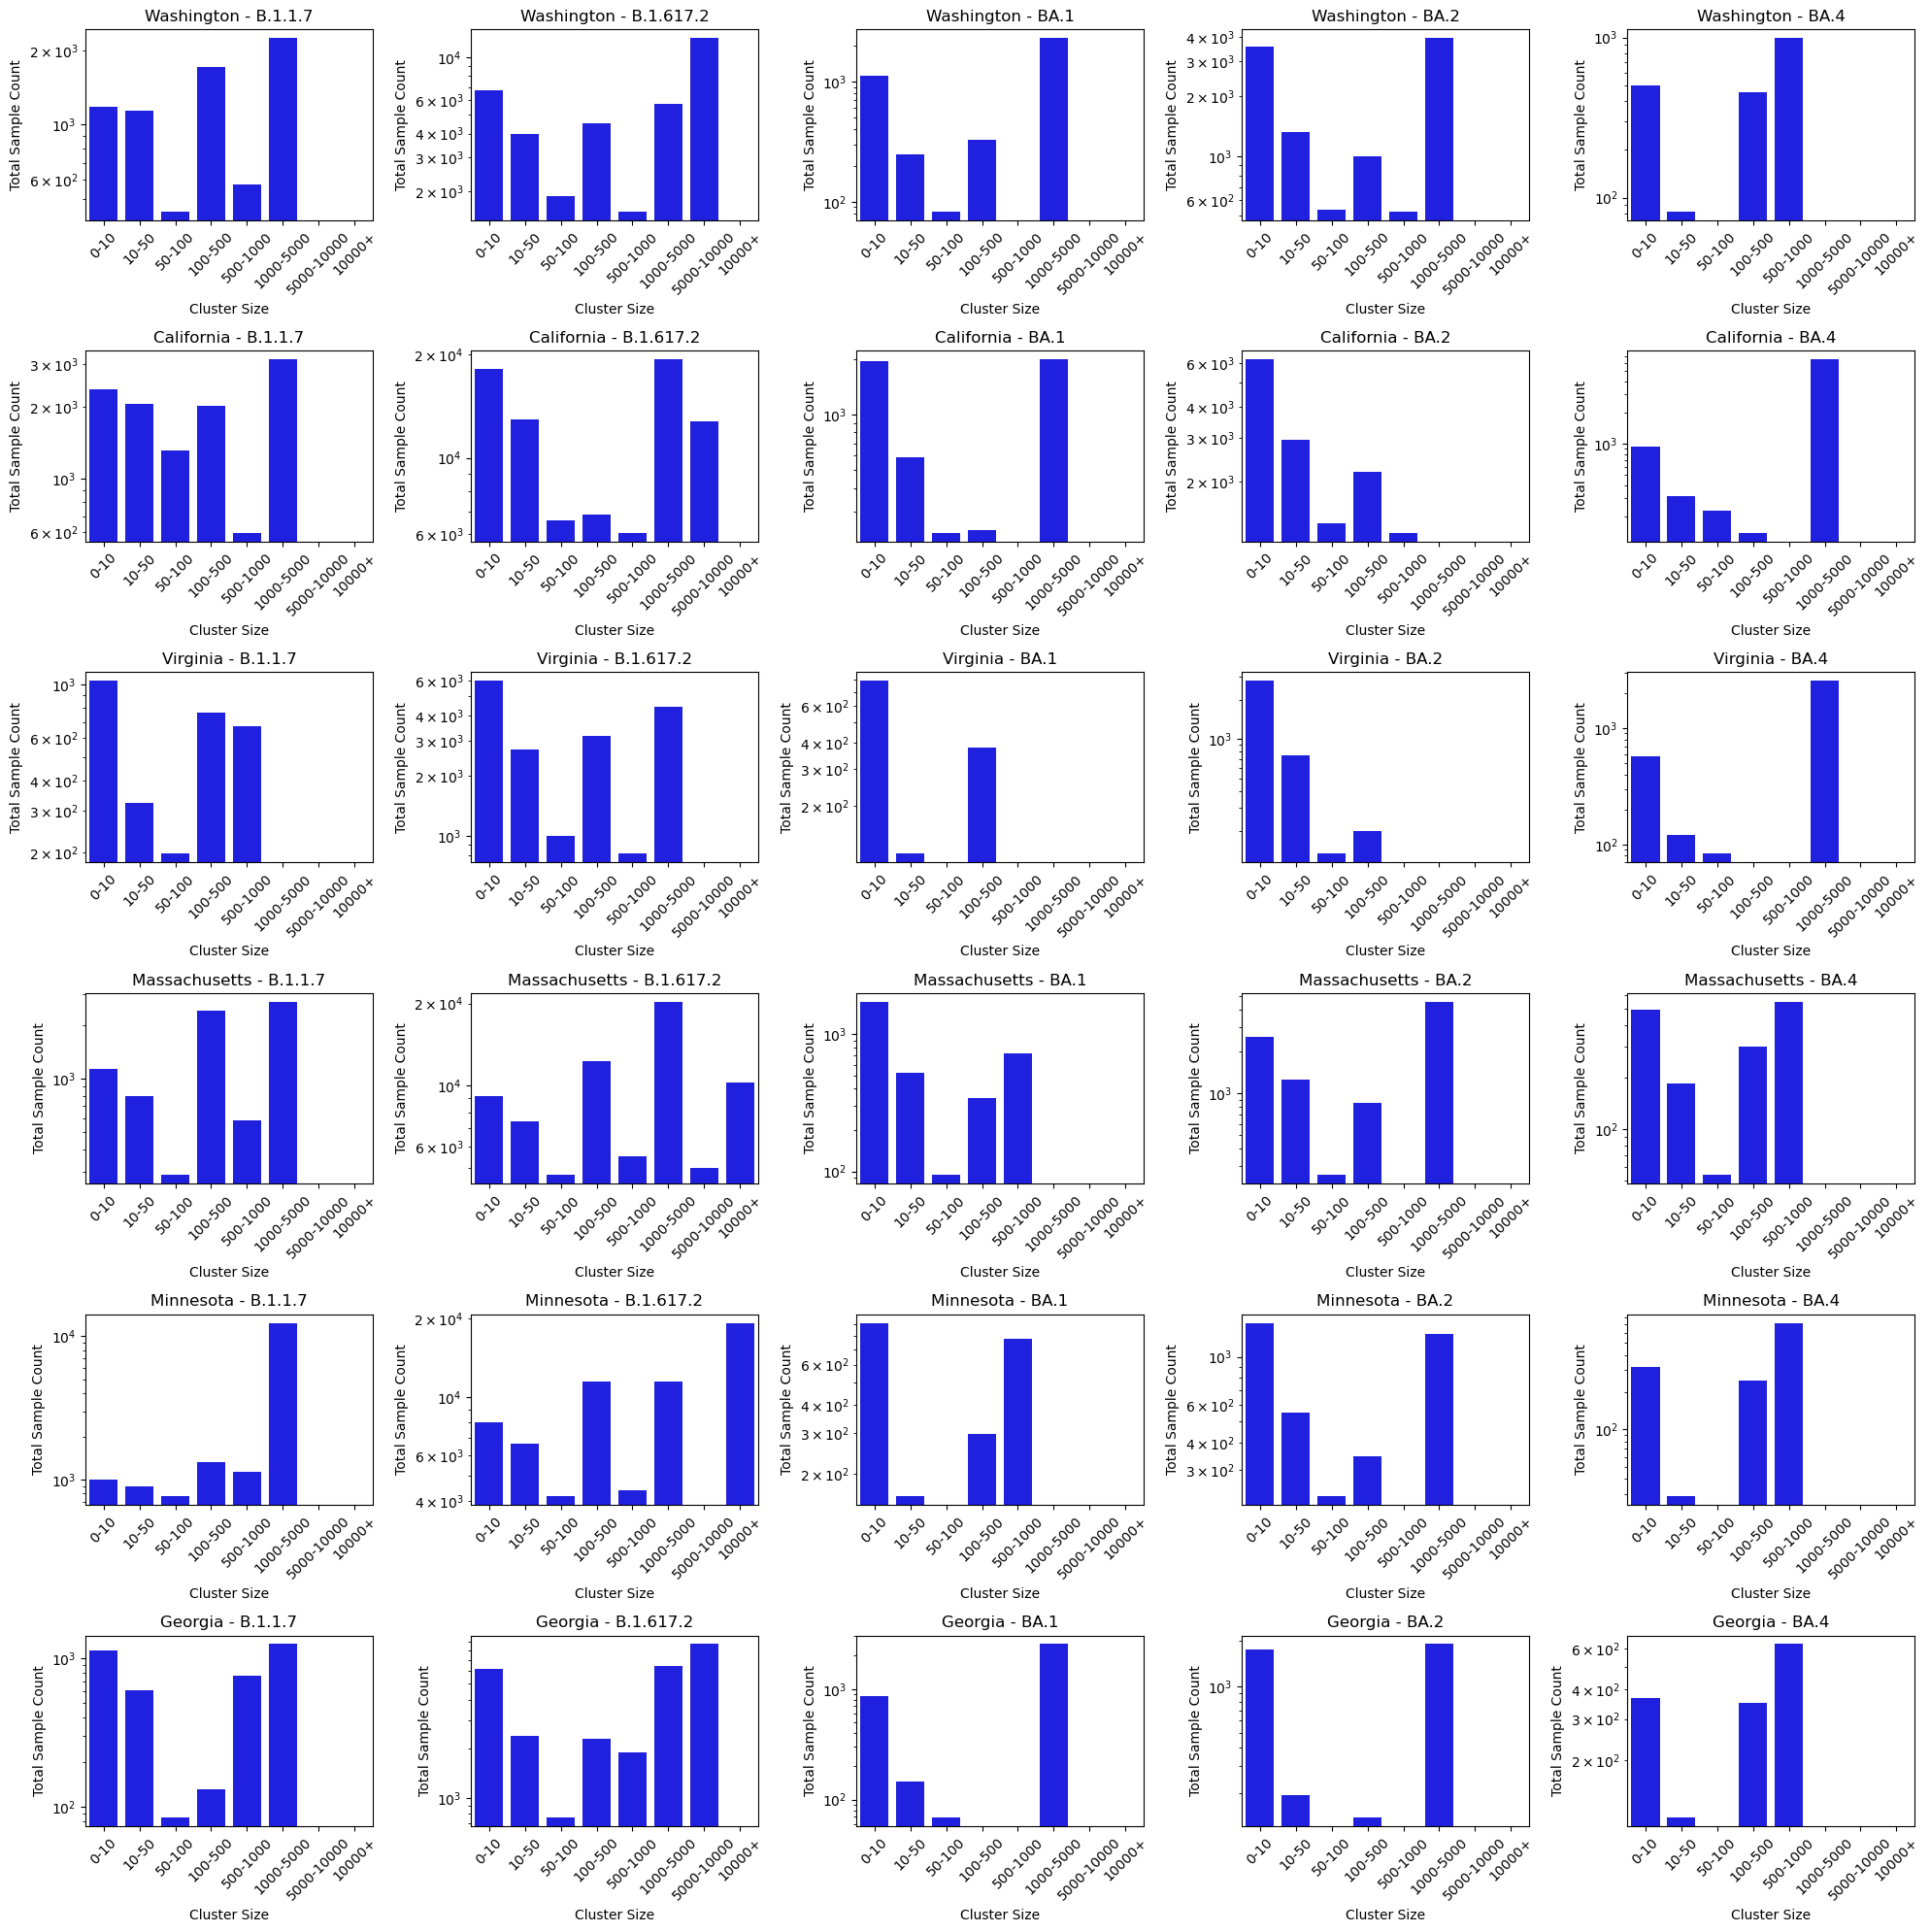

In [41]:
def plot_size_dist(df, locations=None, lineages=None):
    #sort by sample_count
    df.sort_values('sample_count', ascending=False).head()
    #target_lineage="B.1.617.2"
    if lineages is not None:
        target_list=lineages
    else:
        target_list = ['B.1.1.7', 'B.1.617.2', 'BA.1', 'BA.2', 'BA.4']
    if locations is None:
        locations = df['region'].unique()


    # Create a 5x5 grid for the plots
    fig, axes = plt.subplots(nrows=len(locations), ncols=len(target_list), figsize=(len(target_list)*4, 20))
    axes = axes.flatten()  # Flatten the axes array for easier indexing

    # Iterate over regions and target lineages
    for idx, (region, target_lineage) in enumerate([(r, t) for r in locations for t in target_list]):
        if idx >= len(axes):  # Ensure we don't exceed the number of subplots
            break
        
        # Filter df for the region and target lineage
        region_df = df[(df['region'] == region) & (df['annotation_3'] == target_lineage)]
        
        # Create a bin size category based on sample_count
        region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000], 
                                        labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000+'])
        
        # Group by bin size and count the sum of sample_count per bin size
        group_by_df = region_df.groupby('bin_size', as_index=False)['sample_count'].sum()
        
        # Plot the bin size vs total sample count
        ax = axes[idx]
        sns.barplot(x='bin_size', y='sample_count', data=group_by_df, color='blue', ax=ax)
        ax.set_title(f'{region} - {target_lineage}')
        ax.set_xlabel('Cluster Size')
        ax.set_ylabel('Total Sample Count')
        ax.set_yscale('log')
        ax.tick_params(axis='x', rotation=45)

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()
plot_size_dist(df)

/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3810/476257050.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['bin_size'] = pd.cut(region_df['sample_count'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, 50000],
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3810/476257050.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_df = region_df.groupby('bin_size', as_index=False)['sample_count'].sum()
/var/folders/pq/2t2l79812g3fsrtcvgbf15580000gq/T/ipykernel_3810/476257050.py:26: SettingWithCopyWarning: 
A value is

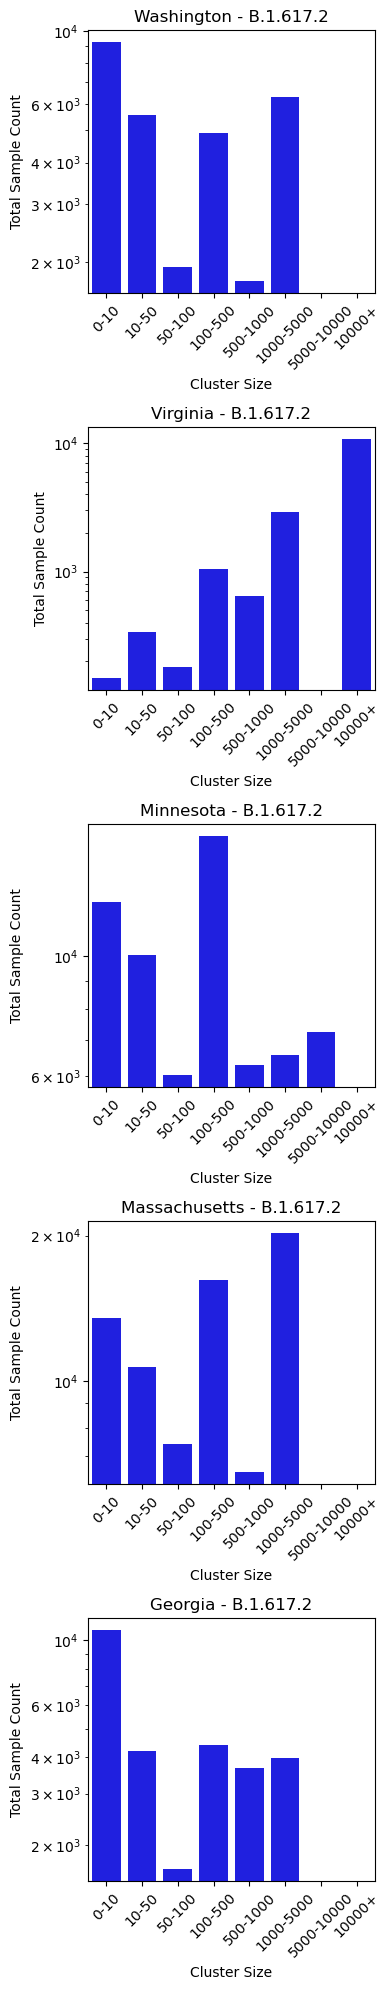

In [42]:
#look at the syn_df for B.1.617.2
plot_size_dist(syn_df,locations=["Washington","Virginia", "Minnesota", "Massachusetts","Georgia"],lineages=["B.1.617.2"])


In [5]:
#for Region Washington and annotation_2 = B.1.617.2 plot the number of rows per week
def plot_importations(df, region, annotation):
    df2 = df[df['annotation_3'] == annotation]
    df2 = df2[df2['region'] == region]
    df3 = df2.groupby(['week_year']).size().reset_index(name='importations')
    df3['seq_count']=df2.groupby(['week_year'])['sample_count'].sum().reset_index(name='sample_count')['sample_count']
    importations = df3['importations'].sum()
    df3 = df3.sort_values(by='week_year')
    df3.plot(x='week_year', y='importations', kind='bar')
    plt.xlabel('Week')
    plt.ylabel('Number of Importations')
    #on a second y axis plot the seq_count using a line plot
    plt.twinx()
    plt.plot(df3['week_year'], df3['seq_count'], color='r')
    #make y axis log scale
    plt.yscale('log')
    plt.ylabel('Number of Sequences')
    #label the minor ticks on y
    plt.minorticks_on()
    #turn on number labels of minor ticks on y
    plt.yticks(minor=True)
    plt.title(f'{annotation} Importations in {region} per Week (total {importations})')
    plt.show()
    #print value counts for the number of regions in df3
    print(df2['region'].value_counts())
    #create a new column in df3 that has the sum of sample_count for each week
    #drop the rows with more than 1000 sample_count
    #wa_df3 = wa_df3[wa_df3['sample_count'] < 1000]
    #create scatter plot
    df3.plot(x='seq_count', y='importations', kind='scatter')
    plt.xlabel('Number of Sequences')
    plt.ylabel('Number of Importations')
    plt.title(f'{annotation} Importations in {region} per Week vs Seqeunces (total {importations})')
    plt.show()
    #write out importations

In [33]:
sample_dates.head()

,sample_dates
0,2021-04-24
1,2021-05-15
2,2021-05-23
3,2021-04-14
4,2021-04-30


In [35]:
df[(df['region'] == "Massachusetts") & (df['annotation_3'] == "B.1.1.7")].sort_values(by='earliest_date')

,cluster_id,sample_count,earliest_date,latest_date,growth_score,span,intro_confidence,parent_confidence,origin_gap,region,inferred_origin,inferred_origin_confidence,annotation_1,annotation_2,mutation_path,samples,annotation_3,week,year,week_year
64624,Massachusetts_node_142801,420,2020-03-15,2021-May-31,0.083991,246,0.0,0.300429,1,Massachusetts,Maryland,0.059406,20I (Alpha),Q.4,A23604G<A4964G<A12162G<A17615G<G28048T<C5388A<...,USA/MA-CDC-ASC210032628/2021|MZ166550.1|2021-0...,B.1.1.7,11,2020,2020-11
64770,Massachusetts_node_176890,178,2020-03-15,2021-May-30,0.054679,104,1.0,0.000000,1,Massachusetts,indeterminate: no information.,0.000000,20I (Alpha),B.1.1.7,C14925T<G25249T<C23520T<T7984C<C19390T<C14120T...,USA/MA-CDC-ASC210048209/2021|MZ075492.1|2021-0...,B.1.1.7,11,2020,2020-11
77972,Massachusetts_node_218169,1,2021-01-06,2021-Jan-06,0.004975,2,1.0,0.000000,1,Massachusetts,indeterminate: no information.,0.000000,20I (Alpha),B.1.1.7,C15928T<C5144T<G28871T<T12865C<C12357T<T15096C...,USA/MA-CDC-STM-A100448/2021|MW519646.1|2021-01-06,B.1.1.7,01,2021,2021-01
73589,Massachusetts_node_164021,2,2021-01-08,2021-Jan-12,0.007036,0,1.0,0.000000,2,Massachusetts,indeterminate: no information.,0.000000,20I (Alpha),B.1.1.7,"T1211G,A17286T<C12970T<G28048T<C5388A<C3267T<C...",USA/MA-MASPHL-02148/2021|MW893804.1|2021-01-12...,B.1.1.7,01,2021,2021-01
78004,Massachusetts_node_131261,1,2021-01-10,2021-Jan-10,0.004975,2,1.0,0.000000,1,Massachusetts,Wisconsin,1.000000,20I (Alpha),B.1.1.7,"C16468T<A17615G<G28048T<C5388A<C3267T<C14676T,...",USA/MA-Broad_CRSP-01239/2021|MW750009.1|2021-0...,B.1.1.7,02,2021,2021-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76740,Massachusetts_node_102080,1,2021-07-28,2021-Jul-28,0.005814,4,1.0,0.333333,5,Massachusetts,Ohio,0.666667,20I (Alpha),B.1.1.7,"T22531A,T28093C,C28280G,T28281A,A28282T<C207T,...",USA/MA-CDC-ASC210234031/2021|OK024164.1|2021-0...,B.1.1.7,30,2021,2021-30
76598,Massachusetts_node_144441,1,2021-08-06,2021-Aug-06,0.005848,3,0.0,0.166667,2,Massachusetts,Illinois,0.428571,20I (Alpha),B.1.1.7,"C28663T<G19086T<C6573T,A14717G,C16877T<G20275T...",USA/MA-CDC-STM-000718680/2021|OL524721.1|2021-...,B.1.1.7,31,2021,2021-31
76662,Massachusetts_node_185789,1,2021-08-07,2021-Aug-07,0.005848,0,1.0,0.250000,2,Massachusetts,Colorado,0.750000,20I (Alpha),B.1.1.7,"A20952G,G22225T<A27880T<C27881T<C27883T<C16308...",USA/MA-CDC-LC0172174/2021|MZ941995.1|2021-08-07,B.1.1.7,31,2021,2021-31
76620,Massachusetts_node_173275,1,2021-08-09,2021-Aug-09,0.005848,1,1.0,0.000000,1,Massachusetts,Virginia,1.000000,20I (Alpha),B.1.1.7,C25162A<C6336T<C4456T<G2782T<C19390T<C14120T<C...,USA/MA-CDCBI-CRSP_B7MIKQFBHCN2OAAV/2021|MZ8012...,B.1.1.7,32,2021,2021-32


In [37]:
threshold_dates={'B.1.1.7':pd.to_datetime('2020-12-01'), 'B.1.617.2':pd.to_datetime('2021-03-01')}

def calc_earliest_date(sample_string,variant):
    #for each row split the sample string based on "," then "|" take the last value, to get an array of dates from each sample string
    sample_dates = pd.DataFrame({'sample_dates':[pd.to_datetime(i.split("|")[-1]) for i in sample_string.split(',')]})
    #get the sample_dates that are after the threshold date for B.1.1.7
    earliest_date=sample_dates[sample_dates['sample_dates'] > threshold_dates[variant]].min()
    return earliest_date

In [40]:


def calc_schedule(df, region, annotations):
    df2 = df[df['region'] == region]
    df2 = df2[df2['annotation_3'].isin(annotations)].sort_values(by='earliest_date')
    df2['earliest_date'] = df2.apply(lambda x: calc_earliest_date(x['samples'], x['annotation_3']) if x['earliest_date'] < threshold_dates[x['annotation_3']] else x['earliest_date'], axis=1)  #get min earliest date
    min_date = df2['earliest_date'].min()
    #drop rows with earliest_date that are na
    df2 = df2.dropna(subset=['earliest_date'])
    #creat tick column by converting earliest_date to datetime and subtracting min_date to create integer
    df2['tick'] = ((pd.to_datetime(df2['earliest_date']) - min_date).dt.days)
    df2['tick'] = df2['tick'].astype(int)
    df3 = df2.groupby(['tick','earliest_date','annotation_3']).size().reset_index(name='importations')
    #df3 rename earliest_date to date and annotation_3 to variant
    df3 = df3.rename(columns={'earliest_date':'date','annotation_3':'variant'})
    df3['seq_count']=df2.groupby(['tick'])['sample_count'].sum().reset_index(name='sample_count')['sample_count']
    #write schedule out to CSV
    df3.to_csv(f'../data/importations/schedules/{region}_schedule.csv', index=False)

In [41]:
annotations= ['B.1.617.2', 'B.1.1.7']
locations=["Washington","Virginia", "Minnesota", "Massachusetts","Georgia"]
for l in locations:
    calc_schedule(df, l, annotations)

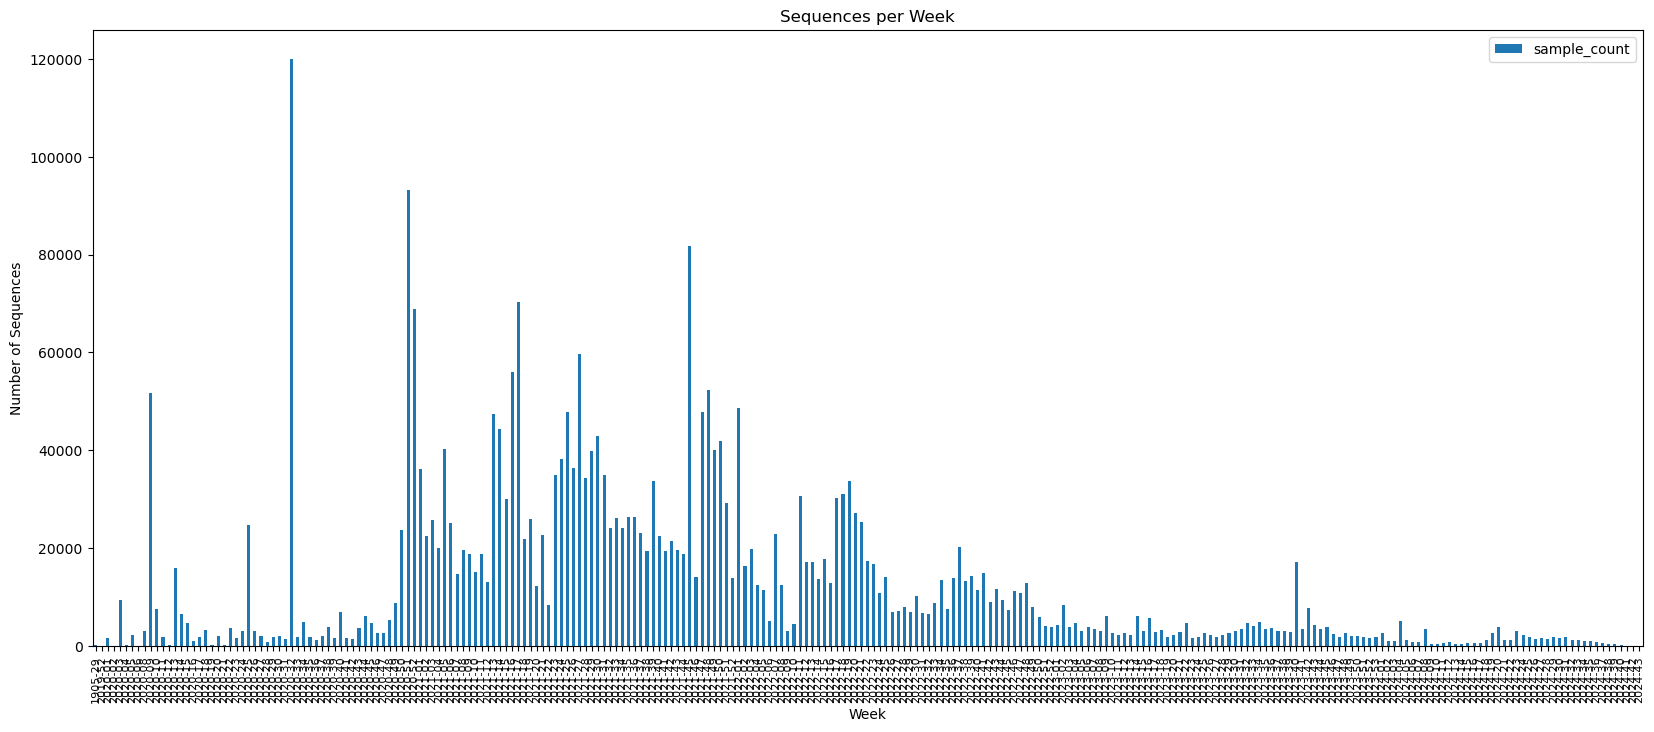

In [16]:
#plot the total number of sequences per week for all data
df3 = df.groupby(['week_year']).size().reset_index(name='count')
df3['sample_count']=df.groupby(['week_year'])['sample_count'].sum().reset_index(name='sample_count')['sample_count']
df3.plot(x='week_year', y='sample_count', kind='bar')
plt.xlabel('Week')
plt.ylabel('Number of Sequences')
plt.title('Sequences per Week')
#make plot wider
plt.gcf().set_size_inches(20, 8)
#make x-axis labels smaller font
plt.xticks(fontsize=8)
plt.show()


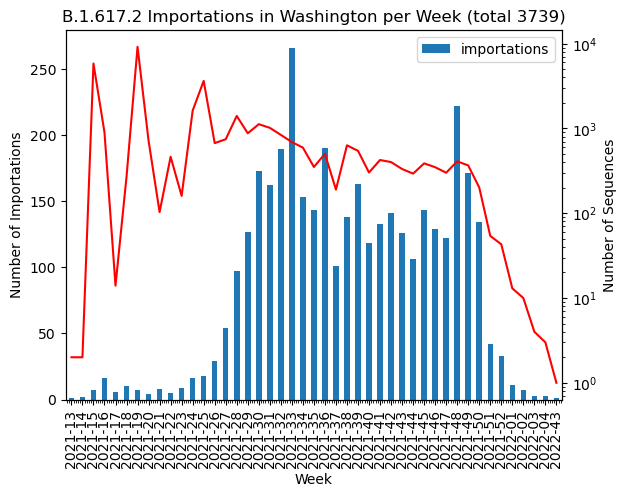

Washington    3739
Name: region, dtype: int64


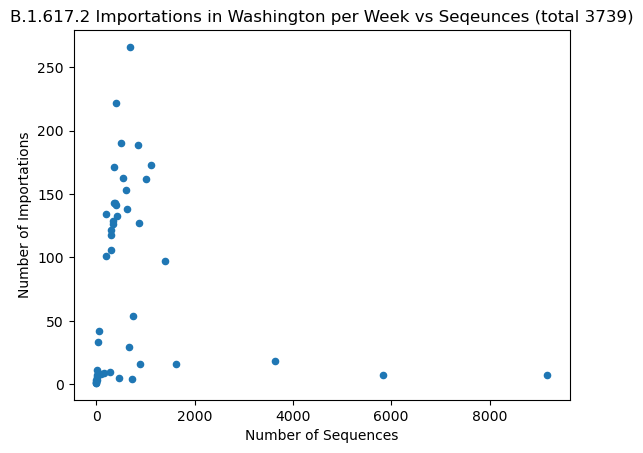

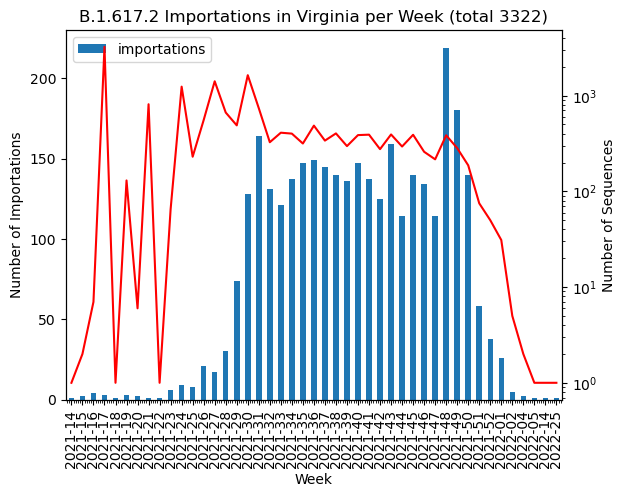

Virginia    3570
Name: region, dtype: int64


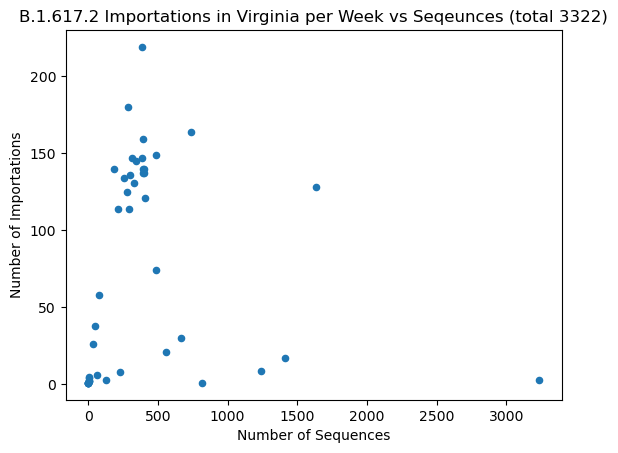

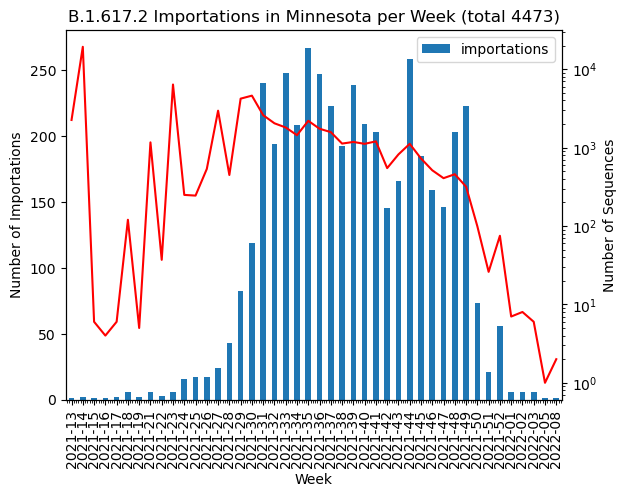

Minnesota    4473
Name: region, dtype: int64


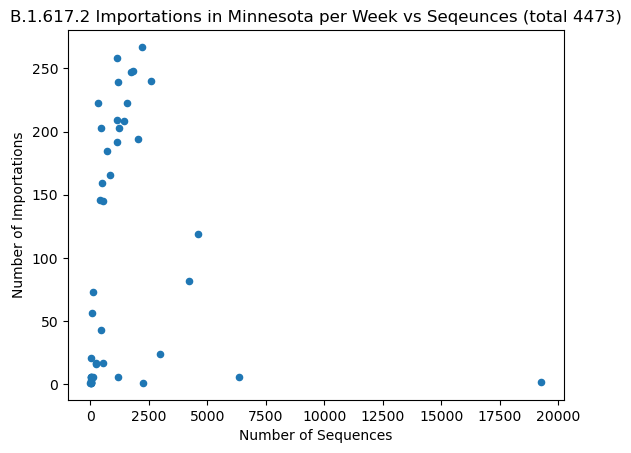

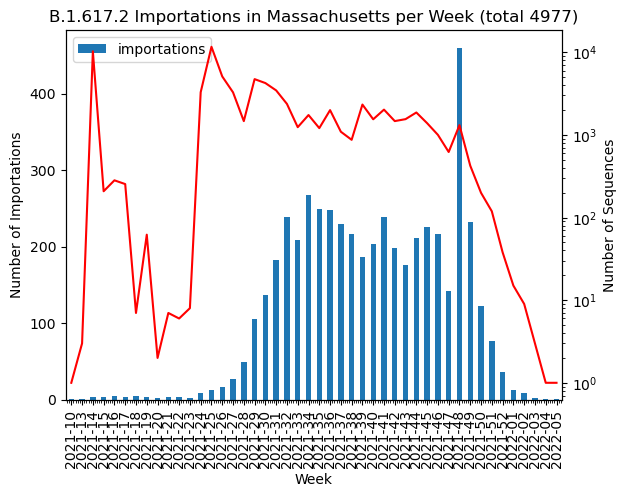

Massachusetts    4977
Name: region, dtype: int64


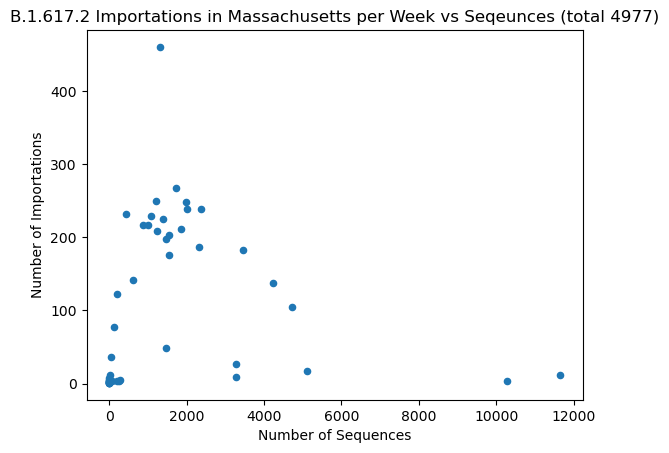

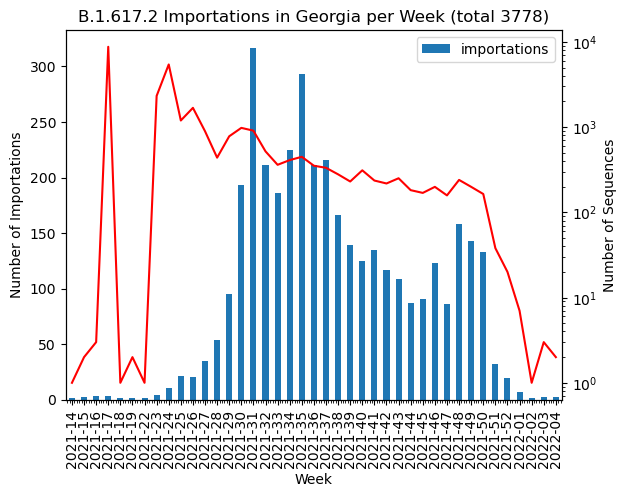

Georgia    3780
Name: region, dtype: int64


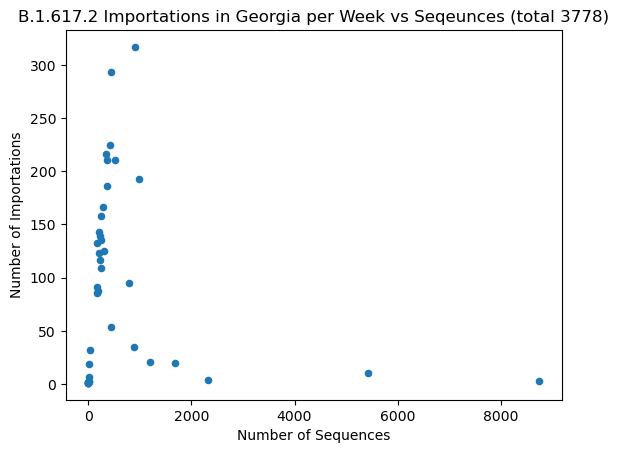

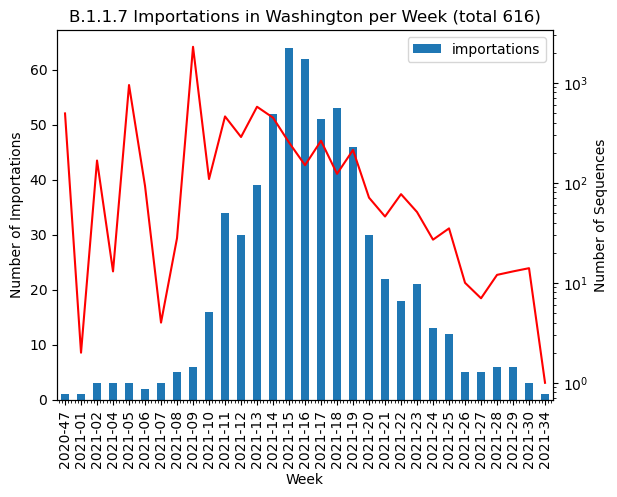

Washington    616
Name: region, dtype: int64


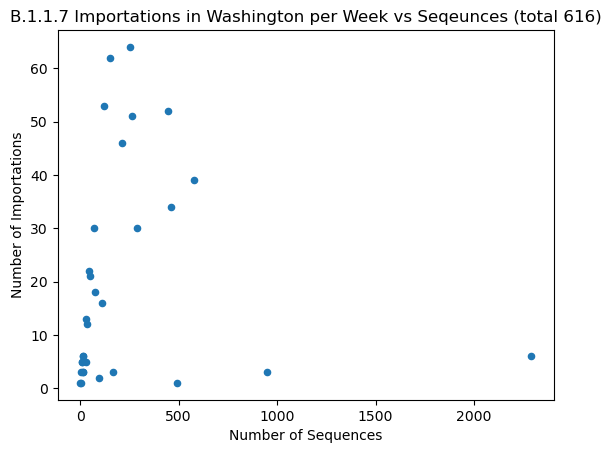

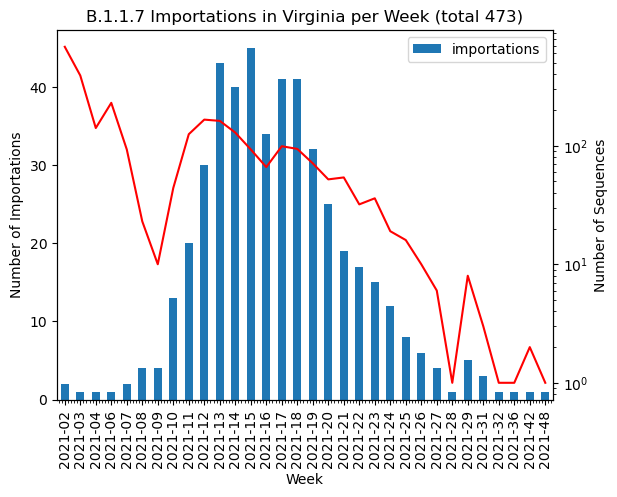

Virginia    582
Name: region, dtype: int64


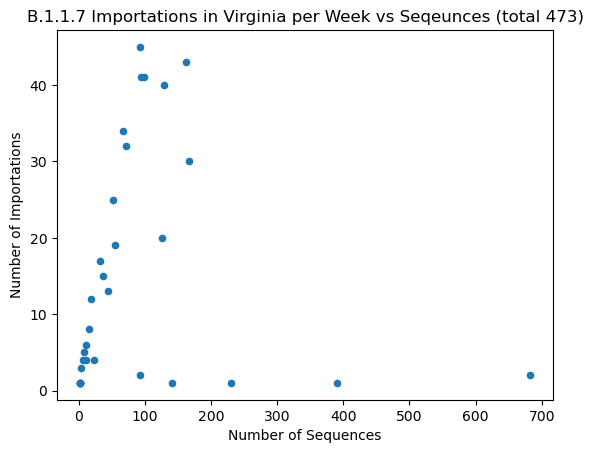

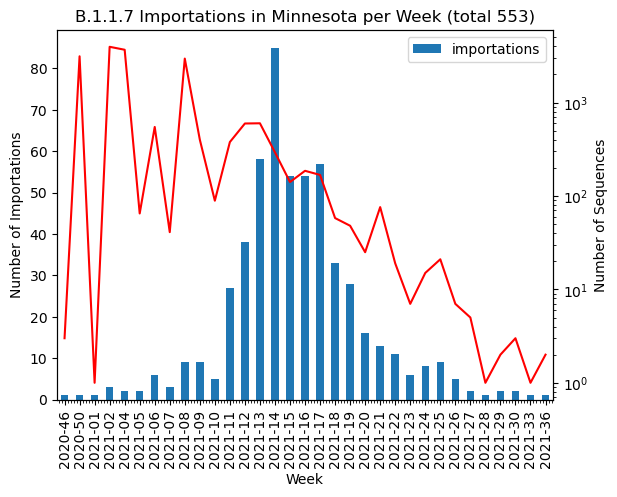

Minnesota    553
Name: region, dtype: int64


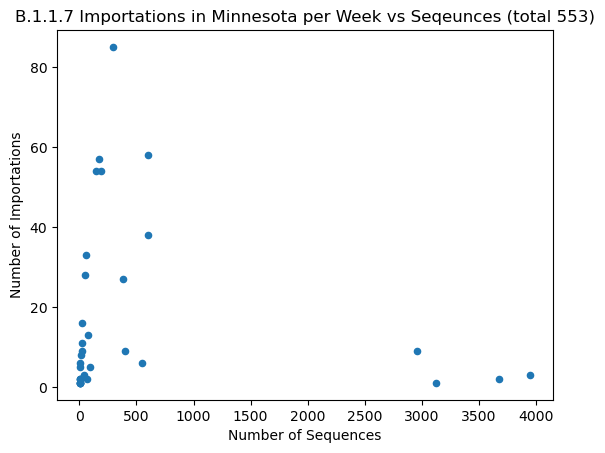

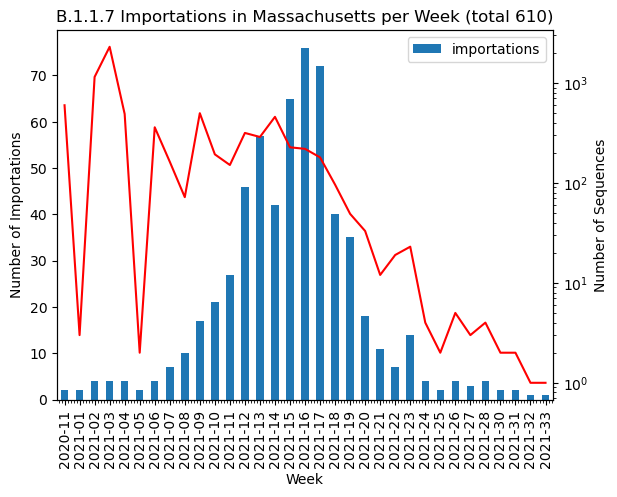

Massachusetts    610
Name: region, dtype: int64


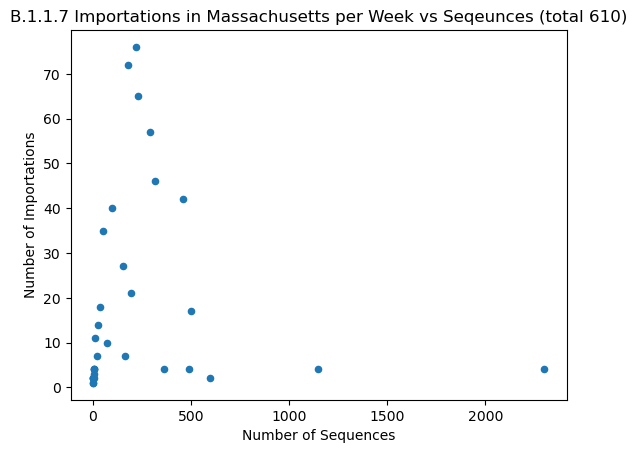

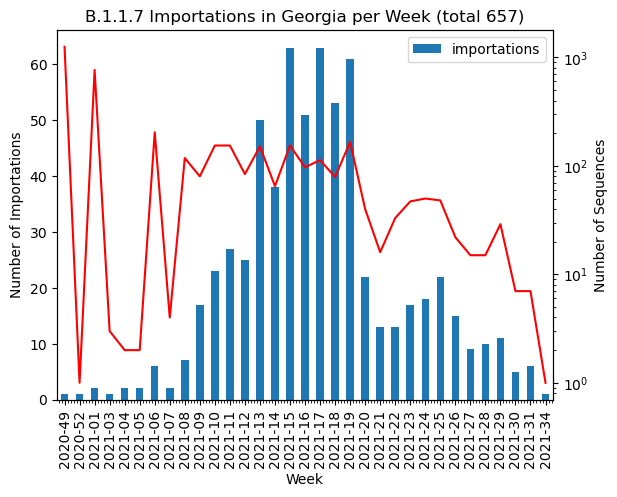

Georgia    658
Name: region, dtype: int64


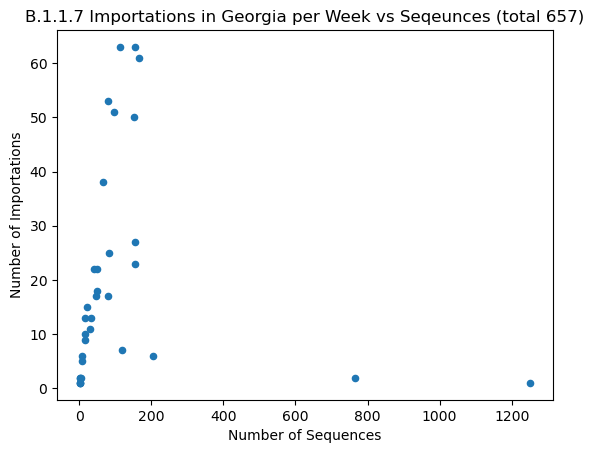

In [57]:
annotations= ['B.1.617.2', 'B.1.1.7']
locations=["Washington","Virginia", "Minnesota", "Massachusetts","Georgia"]
for a in annotations:
    for l in locations:
        plot_importations(df, l, a)